# Vizzes

In [25]:
import os
import os.path as osp
if osp.split(os.getcwd())[-1] == 'notebooks':
    os.chdir('..')

os.getcwd()

'e:\\Edoardo\\Education\\SportDataCampus\\ScoutingAgent'

## Shots

In [26]:
# Cella 1 — Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch, FontManager
from mplsoccer import VerticalPitch, FontManager

In [27]:
# Cella 2 — Preparazione colonne gold + split gol / non-gol

def prepare_gold_shots_for_plot(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Da righe `gold_match_shot_event`: location_x/y, shot_xg, shot_is_goal.
    Ritorna (df_non_goal, df_goal) con colonne x, y, xg.
    """
    out = df.copy()

    if "x" not in out.columns:
        out["x"] = pd.to_numeric(out["location_x"], errors="coerce")
    if "y" not in out.columns:
        out["y"] = pd.to_numeric(out["location_y"], errors="coerce")
    if "xg" not in out.columns:
        out["xg"] = pd.to_numeric(out.get("shot_xg"), errors="coerce").fillna(0.0)
    else:
        out["xg"] = pd.to_numeric(out["xg"], errors="coerce").fillna(0.0)

    if "shot_is_goal" in out.columns:
        is_goal = out["shot_is_goal"].astype(bool)
    else:
        # fallback raro
        is_goal = out.get("shot_outcome", pd.Series("", index=out.index)).astype(str).str.contains(
            "goal", case=False, na=False
        )

    out = out.dropna(subset=["x", "y"])
    out["x"] = out["x"].clip(0, 100)
    out["y"] = out["y"].clip(0, 100)

    df_goals = out[is_goal].copy()
    df_non = out[~is_goal].copy()
    return df_non, df_goals

In [28]:
def plot_gold_shots_mpl_style(
    df_shots: pd.DataFrame,
    title: str,
    *,
    figsize=(12, 10),
    font_prop=None,
    pitch=None,
    edgecolors="#b94b75",
    xg_scale=1900,
    xg_offset=100,
):
    df_non, df_goals = prepare_gold_shots_for_plot(df_shots)

    if pitch is None:
        pitch = VerticalPitch(
            pitch_type="wyscout",
            pitch_length=100,
            pitch_width=100,
            half=True,
            pad_bottom=0.5,
            goal_type="box",
            goal_alpha=0.8,
        )

    fig, ax = pitch.draw(figsize=figsize)

    if not df_non.empty:
        pitch.scatter(
            df_non["x"],
            df_non["y"],
            s=(df_non["xg"] * xg_scale) + xg_offset,
            edgecolors=edgecolors,
            c="None",
            hatch="///",
            marker="o",
            ax=ax,
        )

    if not df_goals.empty:
        pitch.scatter(
            df_goals["x"],
            df_goals["y"],
            s=(df_goals["xg"] * xg_scale) + xg_offset,
            edgecolors=edgecolors,
            linewidths=0.6,
            c="white",
            marker="football",
            ax=ax,
        )

    ax.text(
        40,
        80,
        s=title,
        size=30,
        fontproperties=font_prop,
        color=pitch.line_color,
        va="center",
        ha="center",
    )

    plt.tight_layout()
    return fig, ax

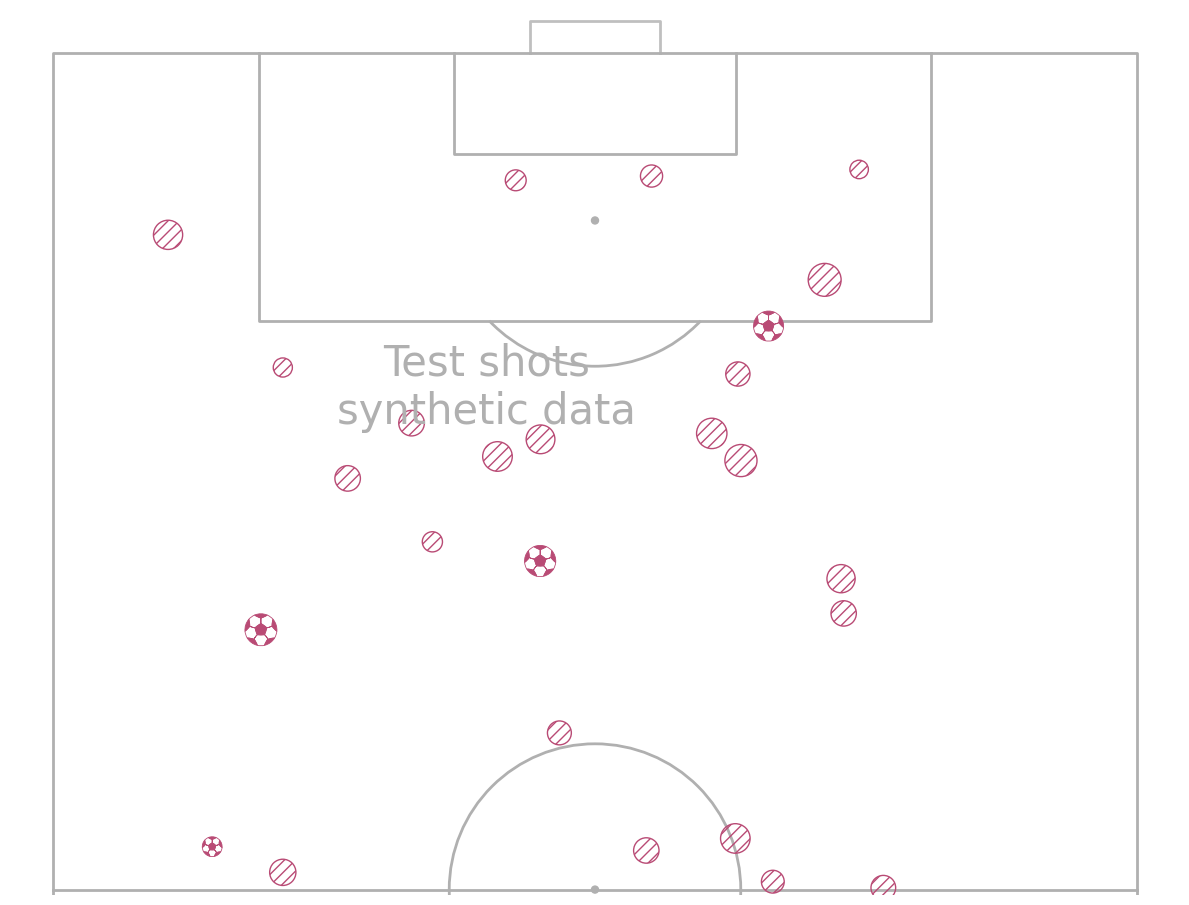

In [29]:
# Cella 5 — Test sintetico (senza BigQuery)

rng = np.random.default_rng(42)
n = 40

df_test = pd.DataFrame(
    {
        "location_x": rng.uniform(15, 95, n),
        "location_y": rng.uniform(10, 90, n),
        "shot_xg": rng.uniform(0.02, 0.25, n),
        "shot_is_goal": rng.random(n) < 0.12,
        "team_id": 675,
        "match_id": 1,
    }
)

fig, ax = plot_gold_shots_mpl_style(
    df_test,
    "Test shots\nsynthetic data",
    
)
plt.show()

In [30]:
# Cella 1 — helper immagini (file locale, URL HTTP, data:image/...;base64,...)

import io
import base64
import requests
import numpy as np
from PIL import Image

def _img_from_any(source: str | None):
    if not source:
        return None

    source = source.strip()
    try:
        # data URL base64
        if source.startswith("data:image"):
            b64 = source.split(",", 1)[1]
            raw = base64.b64decode(b64)
            return np.array(Image.open(io.BytesIO(raw)).convert("RGBA"))

        # URL HTTP(S)
        if source.startswith("http://") or source.startswith("https://"):
            r = requests.get(source, timeout=15)
            r.raise_for_status()
            return np.array(Image.open(io.BytesIO(r.content)).convert("RGBA"))

        # path locale
        return np.array(Image.open(source).convert("RGBA"))
    except Exception:
        return None

In [143]:
def add_header_branding(
    fig,
    title: str,
    *,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source: str | None = None,
    player_img_source: str | None = None,
    header_center_y: float = 1,  # asse comune titolo + immagini
    logo_w: float = 0.16,
    logo_h: float = 0.11,
    right_h: float = 0.10,
    right_w_single: float = 0.08,
    right_w_double: float = 0.07,
):
    fig.subplots_adjust(top=0.84)

    fig.text(
        0.5,
        header_center_y,
        title,
        ha="center",
        va="center",  # così il blocco (anche 2 righe) è centrato su header_center_y
        fontsize=28,
        fontweight="bold",
        color="#A8A9AD",
    )

    def _axes_centered(x0, w, h):
        bottom = header_center_y - h / 2
        return fig.add_axes([x0, bottom, w, h])

    left_img = _img_from_any(left_logo_path)
    if left_img is not None:
        ax_left = _axes_centered(0.03, logo_w, logo_h)
        ax_left.imshow(left_img)
        ax_left.axis("off")

    team_img = _img_from_any(team_img_source)
    player_img = _img_from_any(player_img_source)

    if player_img is not None and team_img is not None:
        ax_p = _axes_centered(0.83, right_w_double, right_h)
        ax_p.imshow(player_img)
        ax_p.axis("off")
        ax_t = _axes_centered(0.91, right_w_double, right_h)
        ax_t.imshow(team_img)
        ax_t.axis("off")
    elif player_img is not None:
        ax_p = _axes_centered(0.90, right_w_single, right_h)
        ax_p.imshow(player_img)
        ax_p.axis("off")
    elif team_img is not None:
        ax_t = _axes_centered(0.90, right_w_single, right_h)
        ax_t.imshow(team_img)
        ax_t.axis("off")

In [144]:
# Cella 3 — integrazione nella tua funzione di plot

def plot_gold_shots_mpl_style(
    df_shots: pd.DataFrame,
    title: str,
    *,
    left_logo_path="images/sport_data_campus.png",
    team_img_source=None,      # image_data_url team
    player_img_source=None,    # image_data_url player (opzionale)
    font_prop=None,
):
    df_non, df_goals = prepare_gold_shots_for_plot(df_shots)

    pitch = VerticalPitch(
        pitch_type="wyscout", pitch_length=100, pitch_width=100,
        half=True, pad_bottom=0.5, goal_type="box", goal_alpha=0.8
    )
    fig, ax = pitch.draw(figsize=(12, 10))

    if not df_non.empty:
        pitch.scatter(
            df_non["x"], df_non["y"],
            s=(df_non["xg"] * 1900) + 100,
            edgecolors="#b94b75", c="None", hatch="///", marker="o", ax=ax
        )

    if not df_goals.empty:
        pitch.scatter(
            df_goals["x"], df_goals["y"],
            s=(df_goals["xg"] * 1900) + 100,
            edgecolors="#b94b75", linewidths=0.6, c="white",
            marker="football", ax=ax
        )

    # header con titolo + immagini
    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
    )

    return fig, ax
    

In [145]:
from __future__ import annotations

import os
from typing import Any

import pandas as pd
from google.cloud import bigquery


def fetch_player_shots_single_match(
    player_id: int,
    match_id: int,
    *,
    project_id: str | None = None,
    dataset: str = "scouting_agent",
) -> dict[str, Any]:
    """
    Tiri del giocatore in una partita + URL immagini (dim_player, dim_team via team_id del tiro).

    Returns:
        {
            "shots": DataFrame (solo colonne tiro, senza URL duplicati),
            "player_image_data_url": str | None,
            "team_image_data_url": str | None,
            "team_id": int | None,
        }
    """
    pid = project_id or os.environ.get("GCP_PROJECT_ID")
    if not pid:
        raise ValueError("Passa project_id= oppure imposta GCP_PROJECT_ID")

    client = bigquery.Client(project=pid)
    fq_shots = f"`{pid}.{dataset}.gold_match_shot_event`"
    fq_player = f"`{pid}.{dataset}.dim_player`"
    fq_team = f"`{pid}.{dataset}.dim_team`"

    sql = f"""
    WITH base AS (
      SELECT
        s.match_id,
        s.event_id,
        s.season_id,
        s.competition_id,
        s.match_period,
        s.minute,
        s.second,
        s.location_x,
        s.location_y,
        s.team_id,
        s.opponent_team_id,
        s.player_id,
        s.shot_is_goal,
        s.shot_xg,
        s.shot_outcome,
        s.shot_body_part,
        p.image_data_url AS player_image_data_url,
        t.image_data_url AS team_image_data_url
      FROM {fq_shots} AS s
      LEFT JOIN {fq_player} AS p ON s.player_id = p.player_id
      LEFT JOIN {fq_team} AS t ON s.team_id = t.team_id
      WHERE s.player_id = @player_id
        AND s.match_id = @match_id
    )
    SELECT * FROM base
    ORDER BY minute, second, event_id
    """
    job = client.query(
        sql,
        job_config=bigquery.QueryJobConfig(
            query_parameters=[
                bigquery.ScalarQueryParameter("player_id", "INT64", player_id),
                bigquery.ScalarQueryParameter("match_id", "INT64", match_id),
            ]
        ),
    )
    df = job.to_dataframe()
    if df.empty:
        return {
            "shots": df,
            "player_image_data_url": None,
            "team_image_data_url": None,
            "team_id": None,
        }

    player_url = df["player_image_data_url"].dropna().iloc[0] if "player_image_data_url" in df.columns else None
    team_url = df["team_image_data_url"].dropna().iloc[0] if "team_image_data_url" in df.columns else None
    tid = int(df["team_id"].iloc[0]) if pd.notna(df["team_id"].iloc[0]) else None

    shot_cols = [
        c
        for c in df.columns
        if c not in ("player_image_data_url", "team_image_data_url")
    ]
    return {
        "shots": df[shot_cols].copy(),
        "player_image_data_url": str(player_url) if player_url is not None and str(player_url).strip() else None,
        "team_image_data_url": str(team_url) if team_url is not None and str(team_url).strip() else None,
        "team_id": tid,
    }

{'shots':    match_id    event_id  season_id  competition_id match_period  minute  \
0   5718123  2921495597     191659             795           1H      16   

   second  location_x  location_y  team_id  opponent_team_id  player_id  \
0      18          87          49      679               687     722567   

   shot_is_goal  shot_xg     shot_outcome shot_body_part  
0         False  0.09287  miss_off_target  head_or_other  , 'player_image_data_url': 'https://cdn5.wyscout.com/photos/players/public/g-235322_100x130.png', 'team_image_data_url': 'https://cdn5.wyscout.com/photos/team/public/47_120x120.png', 'team_id': 679}


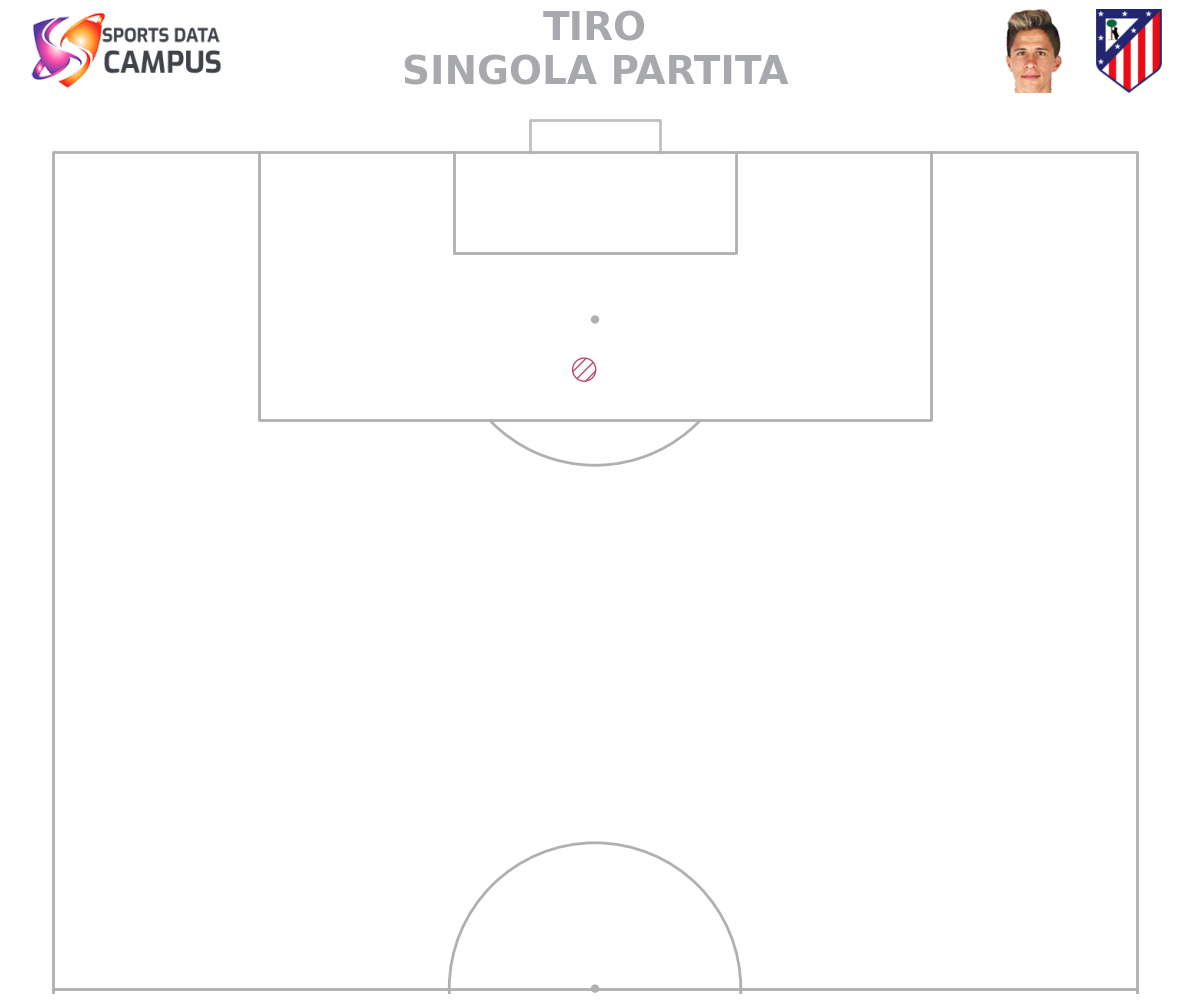

In [146]:
out = fetch_player_shots_single_match(player_id=722567, match_id=5718123)
print(out)
fig, ax = plot_gold_shots_mpl_style(
    out["shots"],
    title="TIRO\nSINGOLA PARTITA",
    player_img_source=out["player_image_data_url"],
    team_img_source=out["team_image_data_url"],
)

## Key Pass e Cross

In [59]:
from __future__ import annotations

from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mplsoccer import VerticalPitch


def _prepare_pass_leading_df(
    df: pd.DataFrame,
    *,
    x_col: str = "x",
    y_col: str = "y",
    end_x_col: str = "end_x",
    end_y_col: str = "end_y",
) -> pd.DataFrame:
    """Se usi gold Wyscout: location_x/y + pass_end_x/y -> x,y,end_x,end_y."""
    out = df.copy()
    mapping = {
        "location_x": "x",
        "location_y": "y",
        "pass_end_x": "end_x",
        "pass_end_y": "end_y",
    }
    for old, new in mapping.items():
        if new not in out.columns and old in out.columns:
            out[new] = out[old]

    need = [x_col, y_col, end_x_col, end_y_col]
    missing = [c for c in need if c not in out.columns]
    if missing:
        raise ValueError(f"Mancano colonne: {missing}. Passa rename o x_col=...")

    out[x_col] = pd.to_numeric(out[x_col], errors="coerce")
    out[y_col] = pd.to_numeric(out[y_col], errors="coerce")
    out[end_x_col] = pd.to_numeric(out[end_x_col], errors="coerce")
    out[end_y_col] = pd.to_numeric(out[end_y_col], errors="coerce")
    return out.dropna(subset=[x_col, y_col, end_x_col, end_y_col])


def plot_passes_leading_to_shots_grid(
    df_pass: pd.DataFrame,
    team1: str,
    team2: str,
    *,
    mask_goal: pd.Series | None = None,
    is_goal_col: str | None = None,
    x_col: str = "x",
    y_col: str = "y",
    end_x_col: str = "end_x",
    end_y_col: str = "end_y",
    pitch_coords: Literal["statsbomb", "wyscout_100"] = "statsbomb",
    endnote_text: str = "@your_twitter_handle",
    font_prop=None,
    line_label: str = "pass leading to shot",
    figheight: float = 12,
) -> tuple[plt.Figure, dict]:
    """
    Stile gallery mplsoccer (VerticalPitch + grid + comet + football marker).

    - mask_goal: Series bool stessa lunghezza di df (priorità su is_goal_col).
    - is_goal_col: es. colonna su df che indica gol sul tiro finale (bool).
    - pitch_coords:
        - 'statsbomb' -> pitch_type statsbomb (df in coordinate StatsBomb).
        - 'wyscout_100' -> custom 100x100 (tipico gold: location_* / pass_end_*).
    """
    d = _prepare_pass_leading_df(
        df_pass, x_col=x_col, y_col=y_col, end_x_col=end_x_col, end_y_col=end_y_col
    )
    if d.empty:
        raise ValueError("DataFrame pass vuoto dopo dropna.")

    if mask_goal is not None:
        mg = mask_goal.reindex(d.index).fillna(False).astype(bool)
    elif is_goal_col is not None and is_goal_col in d.columns:
        mg = d[is_goal_col].fillna(False).astype(bool)
    else:
        mg = pd.Series(False, index=d.index)

   
    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        pitch_color="#22312b",
        line_color="#c7d5cc",
        half=True,
        pad_top=2,
    )

    fig, axs = pitch.grid(
        endnote_height=0.03,
        endnote_space=0,
        figheight=figheight,
        title_height=0.08,
        title_space=0,
        axis=False,
        grid_height=0.82,
    )
    fig.set_facecolor("#22312b")

    pitch.lines(
        d[x_col],
        d[y_col],
        d[end_x_col],
        d[end_y_col],
        lw=10,
        transparent=True,
        comet=True,
        cmap="jet",
        label=line_label,
        ax=axs["pitch"],
    )

    g = d[mg]
    ng = d[~mg]

    if not g.empty:
        pitch.scatter(
            g[end_x_col],
            g[end_y_col],
            s=700,
            marker="football",
            edgecolors="black",
            c="white",
            zorder=2,
            label="goal",
            ax=axs["pitch"],
        )
    if not ng.empty:
        pitch.scatter(
            ng[end_x_col],
            ng[end_y_col],
            edgecolors="white",
            c="#22312b",
            s=700,
            zorder=2,
            label="shot",
            ax=axs["pitch"],
        )

    kw = dict(fontsize=25, color="#dee6ea")
    if font_prop is not None:
        kw["fontproperties"] = font_prop

    axs["endnote"].text(1, 0.5, endnote_text, va="center", ha="right", **kw)

    axs["title"].text(
        0.5,
        0.5,
        f"{team1} passes leading to shots \n vs {team2}",
        va="center",
        ha="center",
        **kw,
    )

    legend = axs["pitch"].legend(
        facecolor="#22312b",
        edgecolor="None",
        loc="lower center",
        handlelength=4,
    )
    for text in legend.get_texts():
        if font_prop is not None:
            text.set_fontproperties(font_prop)
        text.set_fontsize(25)

    return fig, axs

In [60]:
from __future__ import annotations

import os
from typing import Literal

import pandas as pd
from google.cloud import bigquery


def fetch_key_passes_and_crosses(
    *,
    match_id: int | None = None,
    player_id: int | None = None,
    team_id: int | None = None,
    season_id: int | None = None,
    competition_id: int | None = None,
    event_type: Literal["both", "key_pass", "cross"] = "both",
    include_free_kick_cross: bool = True,
    include_shot_assist_as_key: bool = True,
    only_accurate: bool = False,
    limit: int = 5000,
    project_id: str | None = None,
    dataset: str = "scouting_agent",
) -> pd.DataFrame:
    """
    Recupera passaggi chiave e/o cross da gold_match_pass_event.
    Restituisce colonne utili per analisi/plot pass map.
    """
    pid = project_id or os.environ.get("GCP_PROJECT_ID")
    if not pid:
        raise ValueError("Passa project_id oppure imposta GCP_PROJECT_ID")

    if match_id is None and player_id is None and team_id is None and season_id is None and competition_id is None:
        raise ValueError("Specifica almeno un filtro (es. match_id o team_id o player_id).")

    if limit < 1:
        limit = 1
    if limit > 20000:
        limit = 20000

    table = f"`{pid}.{dataset}.gold_match_pass_event`"

    # Definizione filtro eventi
    if event_type == "key_pass":
        key_expr = "is_key_pass OR is_shot_assist" if include_shot_assist_as_key else "is_key_pass"
        event_filter = f"({key_expr})"
    elif event_type == "cross":
        cross_expr = "is_cross OR is_free_kick_cross" if include_free_kick_cross else "is_cross"
        event_filter = f"({cross_expr})"
    else:  # both
        key_expr = "is_key_pass OR is_shot_assist" if include_shot_assist_as_key else "is_key_pass"
        cross_expr = "is_cross OR is_free_kick_cross" if include_free_kick_cross else "is_cross"
        event_filter = f"(({key_expr}) OR ({cross_expr}))"

    sql = f"""
    SELECT
      match_id,
      event_id,
      season_id,
      competition_id,
      match_period,
      minute,
      second,
      team_id,
      opponent_team_id,
      player_id,
      recipient_player_id,
      location_x,
      location_y,
      pass_end_x,
      pass_end_y,
      pass_accurate,
      pass_length_m,
      pass_angle_deg,
      pass_height,
      is_key_pass,
      is_shot_assist,
      is_cross,
      is_free_kick_cross,
      is_progressive_pass,
      is_through_pass,
      is_pass_to_final_third,
      is_pass_to_penalty_area
    FROM {table}
    WHERE {event_filter}
      {"AND match_id = @match_id" if match_id is not None else ""}
      {"AND player_id = @player_id" if player_id is not None else ""}
      {"AND team_id = @team_id" if team_id is not None else ""}
      {"AND season_id = @season_id" if season_id is not None else ""}
      {"AND competition_id = @competition_id" if competition_id is not None else ""}
      {"AND pass_accurate IS TRUE" if only_accurate else ""}
    ORDER BY match_id, minute, second, event_id
    LIMIT @limit
    """

    params: list[bigquery.ScalarQueryParameter] = [
        bigquery.ScalarQueryParameter("limit", "INT64", int(limit))
    ]
    if match_id is not None:
        params.append(bigquery.ScalarQueryParameter("match_id", "INT64", int(match_id)))
    if player_id is not None:
        params.append(bigquery.ScalarQueryParameter("player_id", "INT64", int(player_id)))
    if team_id is not None:
        params.append(bigquery.ScalarQueryParameter("team_id", "INT64", int(team_id)))
    if season_id is not None:
        params.append(bigquery.ScalarQueryParameter("season_id", "INT64", int(season_id)))
    if competition_id is not None:
        params.append(bigquery.ScalarQueryParameter("competition_id", "INT64", int(competition_id)))

    client = bigquery.Client(project=pid)
    job = client.query(sql, job_config=bigquery.QueryJobConfig(query_parameters=params))
    return job.to_dataframe()

In [66]:
# 2) Solo key pass di un giocatore in una partita
df_pass = fetch_key_passes_and_crosses(
    player_id=722567, 
    match_id=5718123,
    include_shot_assist_as_key=True,
    only_accurate=False,
)
print(df_pass[["event_id", "minute", "second", "is_key_pass", "is_shot_assist"]].head())

     event_id  minute  second  is_key_pass  is_shot_assist
0  2921495407       3      45        False            True
1  2921495411       4      30        False            True
2  2921495472      10      41        False           False
3  2921495641      18      45        False           False
4  2921495895      29      22         True            True


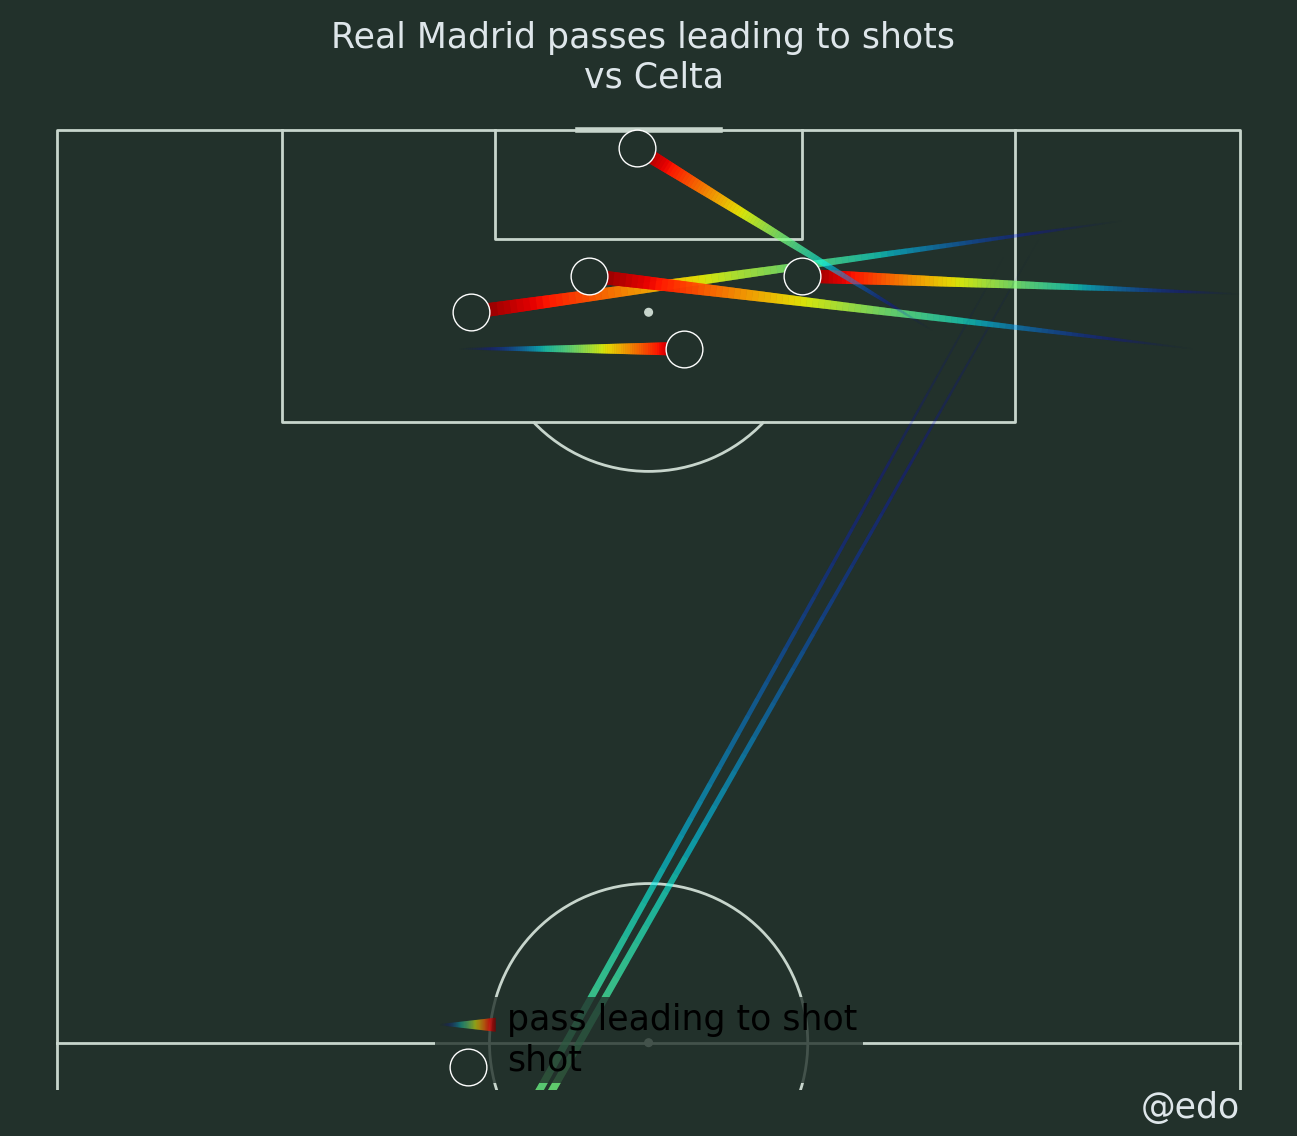

In [ ]:
fig, axs = plot_passes_leading_to_shots_grid(
    df_pass,
    "Real Madrid",
    "Celta",
    is_goal_col="shot_is_goal",   # o mask_goal=...
    pitch_coords="wyscout_100",
    endnote_text="@edo",
    
)
plt.show()

In [172]:
def plot_crosses_same_pitch_as_pass_leading(
    df_cross: pd.DataFrame,
    title: str,
    *,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source=None,
    player_img_source=None,
    header_center_y: float = 0.915,
    header_title_color: str = "#A8A9AD",
    figheight: float = 12,
    legend_ncol: int = 3,
    line_lw: float = 6,
    line_cmap: str = "jet",
    # key pass: più differenziato
    key_pass_color: str = "#5ce1ff",
    key_pass_lw_scale: float = 0.55,  # frazione di line_lw (più sottile)
) -> tuple[plt.Figure, plt.Axes]:
    d = df_cross.copy()
    for c in ["location_x", "location_y", "pass_end_x", "pass_end_y"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    x1 = d["pass_end_x"].fillna(0.0)
    y1 = d["pass_end_y"].fillna(0.0)
    blocked = (x1 == 0) & (y1 == 0)

    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        half=True,
        pad_bottom=0.5,
        goal_type="box",
        goal_alpha=0.8,
    )

    fig, ax_pitch = pitch.draw(figsize=(12, 10))

    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
    )

    ks = d["is_key_pass"].fillna(False).astype(bool) if "is_key_pass" in d.columns else pd.Series(False, index=d.index)
    sa = d["is_shot_assist"].fillna(False).astype(bool) if "is_shot_assist" in d.columns else pd.Series(False, index=d.index)

    both = ks & sa
    only_sa = sa & ~ks
    only_kp = ks & ~sa
    base = ~blocked

    def _lines_comet(sub, label, cmap, lw, z):
        sub = sub & base
        dd = d[sub].dropna(subset=["location_x", "location_y", "pass_end_x", "pass_end_y"])
        if dd.empty:
            return
        pitch.lines(
            dd["location_x"],
            dd["location_y"],
            dd["pass_end_x"],
            dd["pass_end_y"],
            lw=lw,
            transparent=True,
            comet=True,
            cmap=cmap,
            label=label,
            ax=ax_pitch,
            zorder=z,
        )

    # Key pass: NO comet, tratteggio, colore fisso (molto diverso dalle comet colorate)
    def _lines_key_pass_dashed(sub, label, lw, z):
        sub = sub & base
        dd = d[sub].dropna(subset=["location_x", "location_y", "pass_end_x", "pass_end_y"])
        if dd.empty:
            return
        pitch.lines(
            dd["location_x"],
            dd["location_y"],
            dd["pass_end_x"],
            dd["pass_end_y"],
            lw=lw,
            color=key_pass_color,
            linestyle=(0, (6, 4)),  # dashed; su alcune versioni prova linestyle="--"
            comet=False,
            alpha=0.95,
            label=label,
            ax=ax_pitch,
            zorder=z,
        )

    _lines_comet(both, "key pass + shot assist", "spring", line_lw + 4, z=4)
    _lines_comet(only_sa, "shot assist", "Greens", line_lw + 2, z=3)
    _lines_key_pass_dashed(only_kp, "key pass", max(1.5, line_lw * key_pass_lw_scale), z=2)

    d_blk = d[blocked].dropna(subset=["location_x", "location_y"])
    if not d_blk.empty:
        pitch.scatter(
            d_blk["location_x"],
            d_blk["location_y"],
            marker="x",
            s=280,
            linewidths=2.5,
            c="#ff6b6b",
            edgecolors="white",
            zorder=6,
            label="Cross Blocked",
            ax=ax_pitch,
        )

    leg = ax_pitch.legend(
        loc="lower center",
        ncol=legend_ncol,
        handlelength=4,
        framealpha=0.92,
    )

    return fig, ax_pitch

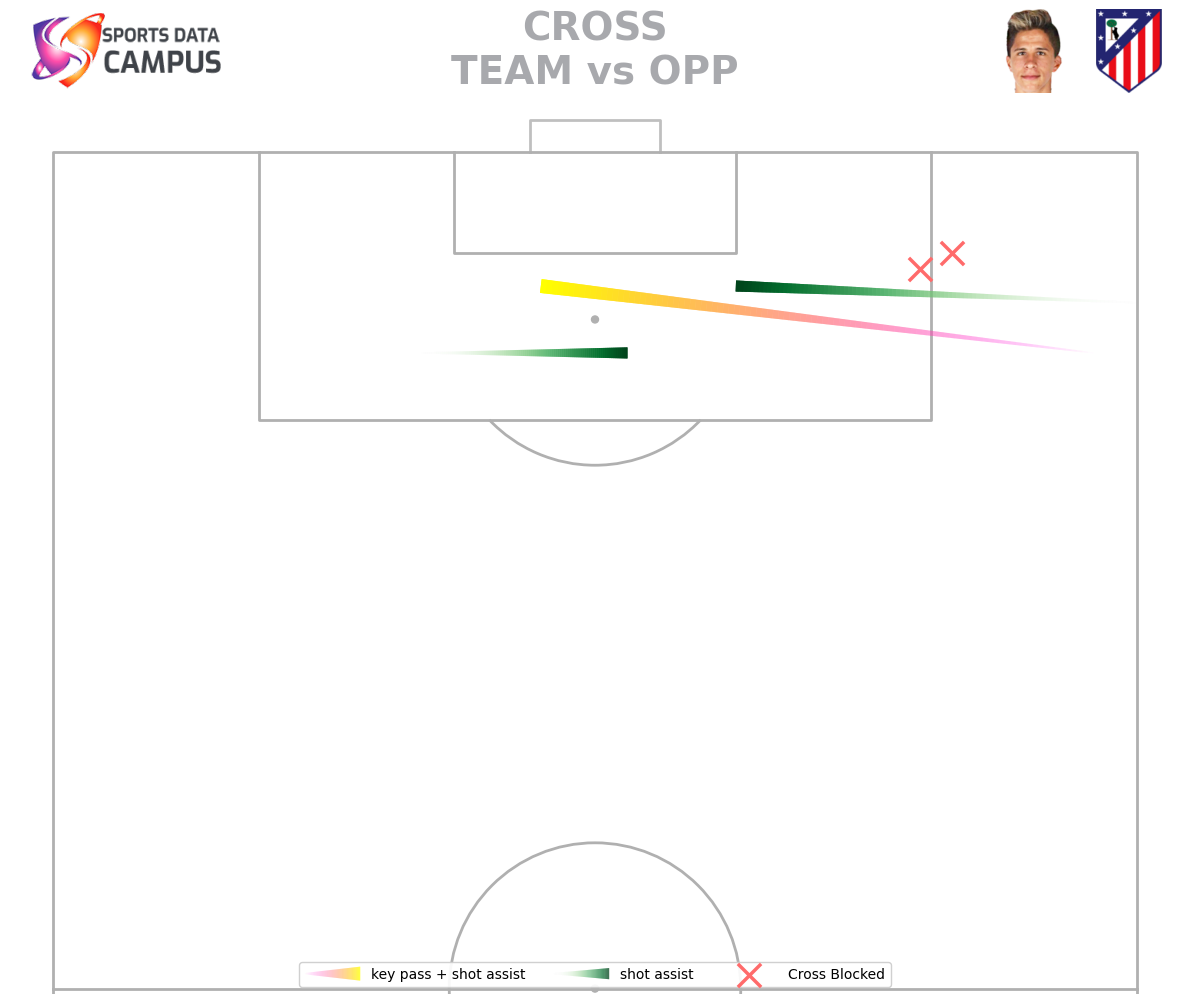

In [173]:

fig, axs = plot_crosses_same_pitch_as_pass_leading(
    df_pass,
    "CROSS\nTEAM vs OPP",
    player_img_source=out["player_image_data_url"],
    team_img_source=out["team_image_data_url"],  # o None
    legend_ncol=3,
)
plt.show()
plt.show()

### Heatmap

In [224]:
# --- Colormap in tema Sports Data Campus (viola → magenta → arancio → giallo) ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SDC_CMAP_WHITE0 = LinearSegmentedColormap.from_list(
    "sdc_w0",
    ["#ffffff", "#2d1b4e", "#7c2d6b", "#e85d8a", "#ff7a33", "#ffd666"],
    N=256,
)

In [175]:
# --- 1) Recupero eventi giocatore in partita (BigQuery) ---

from __future__ import annotations

import os
import pandas as pd
from google.cloud import bigquery


def fetch_player_events_single_match(
    match_id: int,
    player_id: int,
    *,
    project_id: str | None = None,
    dataset: str = "scouting_agent",
    limit: int = 20000,
) -> pd.DataFrame:
    """
    Tutti gli eventi in silver_match_event per (match_id, player_id).
    Solo righe con posizione valida (per heatmap).
    """
    pid = project_id or os.environ.get("GCP_PROJECT_ID")
    if not pid:
        raise ValueError("Imposta GCP_PROJECT_ID o passa project_id=")

    lim = max(1, min(int(limit), 50000))
    table = f"`{pid}.{dataset}.silver_match_event`"

    sql = f"""
    SELECT
      match_id,
      event_id,
      season_id,
      competition_id,
      match_period,
      minute,
      second,
      match_timestamp,
      type_primary,
      type_secondary_json,
      location_x,
      location_y,
      team_id,
      opponent_team_id,
      player_id,
      possession_id,
      possession_team_id
    FROM {table}
    WHERE match_id = @match_id
      AND player_id = @player_id
      AND location_x IS NOT NULL
      AND location_y IS NOT NULL
    ORDER BY minute, second, event_id
    LIMIT @limit
    """
    cfg = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("match_id", "INT64", int(match_id)),
            bigquery.ScalarQueryParameter("player_id", "INT64", int(player_id)),
            bigquery.ScalarQueryParameter("limit", "INT64", lim),
        ]
    )
    return bigquery.Client(project=pid).query(sql, job_config=cfg).to_dataframe()

In [201]:
def plot_player_match_hex_heatmap(
    df_events: pd.DataFrame,
    title: str,
    *,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source=None,
    player_img_source=None,
    x_col: str = "location_x",
    y_col: str = "location_y",
    figsize=(4.8, 6.4),  # un filo più largo per la colorbar
    gridsize=(12, 12),
    cmap=None,
    mincnt: int = 1,
    pitch_half: bool = True,
    colorbar: bool = True,
    cbar_label: str = "Conteggio eventi",
) -> tuple[plt.Figure, plt.Axes]:
    if cmap is None:
        cmap = SDC_CMAP

    d = df_events.copy()
    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[x_col, y_col])
    if d.empty:
        raise ValueError("Nessun evento con coordinate valide.")

    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        half=pitch_half,
        pad_bottom=0.5,
        goal_type="box",
        goal_alpha=0.8,
        pitch_color="white",
        line_color="#000009",
        line_zorder=2,
    )

    fig, ax = pitch.draw(figsize=figsize)

    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
    )

    out = pitch.hexbin(
        d[x_col],
        d[y_col],
        ax=ax,
        edgecolors="#f4f4f4",
        gridsize=gridsize,
        cmap=cmap,
        mincnt=mincnt,
    )
    # mplsoccer: spesso ritorna la collection; altrimenti ultima collection sull'asse
    mappable = out if out is not None else ax.collections[-1]

    if colorbar:
        cbar = fig.colorbar(
            mappable,
            ax=ax,
            shrink=0.72,
            pad=0.04,
            location="right",
        )
        cbar.set_label(cbar_label, color="#333333", fontsize=10)
        cbar.ax.tick_params(colors="#333333", labelsize=9)
        cbar.outline.set_edgecolor("#cccccc")

    fig.subplots_adjust(right=0.88)  # se la barra taglia, prova 0.85–0.90
    plt.tight_layout()
    return fig, ax

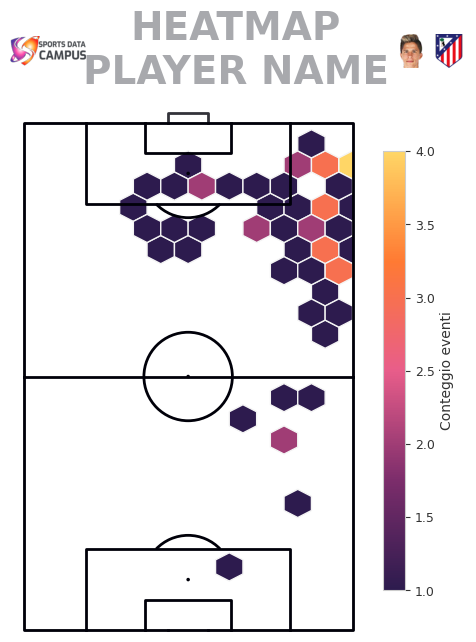

In [202]:
df_ev = fetch_player_events_single_match(
     player_id=722567, 
    match_id=5718123,
)

# opzionale: stesse query dim di prima per player_image_data_url / team_image_data_url
fig, ax = plot_player_match_hex_heatmap(
    df_ev,
    "HEATMAP\nPLAYER NAME",
    player_img_source=out['player_image_data_url'],
    team_img_source=out['team_image_data_url'],
    pitch_half=False,
)
plt.show()

In [235]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.axes import Axes
from matplotlib.colors import Normalize
from matplotlib.contour import QuadContourSet

from mplsoccer import VerticalPitch




def plot_player_match_kde_heatmap(
    df_events: pd.DataFrame,
    title: str,
    *,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source=None,
    player_img_source=None,
    x_col: str = "location_x",
    y_col: str = "location_y",
    figsize=(5.2, 6.8),
    cmap=None,
    pitch_half: bool = False,
    fill: bool = True,
    levels: int = 100,
    thresh: float = 0,
    cut: int = 4,
    colorbar: bool = True,
    cbar_label: str = "Densità (KDE)",
) -> tuple[plt.Figure, plt.Axes]:
    if cmap is None:
        cmap = SDC_CMAP

    d = df_events.copy()
    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[x_col, y_col])
    if len(d) < 3:
        raise ValueError("Servono almeno ~3 punti con coordinate per una KDE stabile.")

    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        half=pitch_half,
        pad_bottom=0.5,
        goal_type="box",
        goal_alpha=0.8,
        pitch_color="white",
        line_color="#000009",
        line_zorder=3,
    )

    fig, ax = pitch.draw(figsize=figsize)
    fig.patch.set_facecolor("white")

    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
    )

    kde_return = pitch.kdeplot(
        d[x_col],
        d[y_col],
        ax=ax,
        fill=fill,
        levels=levels,
        thresh=0,
        cut=4,
        cmap=cmap,
        zorder=1,
        alpha=0.92,
    )

    

    

    return fig, ax

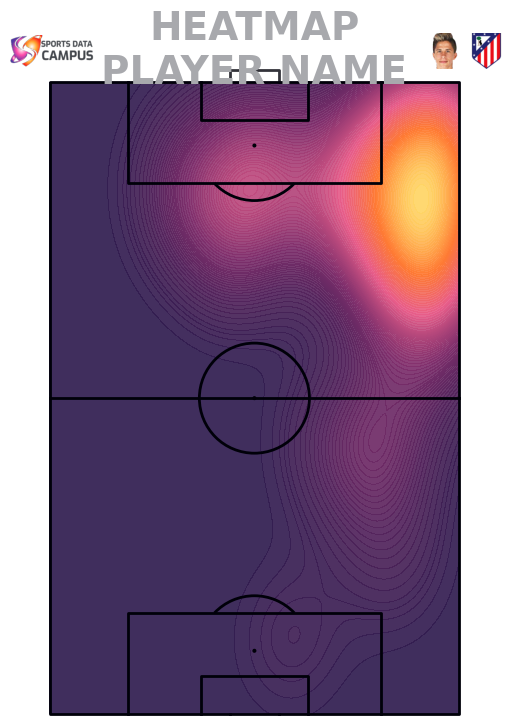

In [236]:
df_ev = fetch_player_events_single_match(
     player_id=722567, 
    match_id=5718123,
)

# opzionale: stesse query dim di prima per player_image_data_url / team_image_data_url
fig, ax = plot_player_match_kde_heatmap(
    df_ev,
    "HEATMAP\nPLAYER NAME",
    player_img_source=out['player_image_data_url'],
    team_img_source=out['team_image_data_url'],
    pitch_half=False,
)
plt.show()

In [237]:
from __future__ import annotations

import os
import pandas as pd
from google.cloud import bigquery


def fetch_passer_recipient_passes(
    match_id: int,
    player_id: int,
    *,
    project_id: str | None = None,
    dataset: str = "scouting_agent",
    limit: int = 50000,
) -> pd.DataFrame:
    """
    Tutti i passaggi da gold_match_pass_event con recipient noto.
    Colonne: start (location_*), end (pass_end_*), recipient_id, nomi da dim_player.
    """
    pid = project_id or os.environ.get("GCP_PROJECT_ID")
    if not pid:
        raise ValueError("GCP_PROJECT_ID o project_id=")

    lim = max(1, min(int(limit), 100_000))
    fq = f"`{pid}.{dataset}.gold_match_pass_event`"
    dp = f"`{pid}.{dataset}.dim_player`"

    sql = f"""
    SELECT
      p.match_id,
      p.event_id,
      p.minute,
      p.second,
      p.location_x AS start_x,
      p.location_y AS start_y,
      p.pass_end_x AS end_x,
      p.pass_end_y AS end_y,
      p.player_id AS passer_id,
      pas.short_name AS passer_name,
      p.recipient_player_id AS recipient_id,
      rec.short_name AS recipient_name
    FROM {fq} AS p
    LEFT JOIN {dp} AS pas ON p.player_id = pas.player_id
    LEFT JOIN {dp} AS rec ON p.recipient_player_id = rec.player_id
    WHERE p.match_id = @match_id
      AND p.player_id = @player_id
      AND p.recipient_player_id IS NOT NULL
      AND p.pass_end_x IS NOT NULL
      AND p.pass_end_y IS NOT NULL
    ORDER BY p.minute, p.second, p.event_id
    LIMIT @limit
    """
    cfg = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("match_id", "INT64", int(match_id)),
            bigquery.ScalarQueryParameter("player_id", "INT64", int(player_id)),
            bigquery.ScalarQueryParameter("limit", "INT64", lim),
        ]
    )
    return bigquery.Client(project=pid).query(sql, job_config=cfg).to_dataframe()

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.axes import Axes
from matplotlib.colors import Normalize
from matplotlib.contour import QuadContourSet

from mplsoccer import VerticalPitch


def _kde_mappable(ax, cmap, kde_return):
    if kde_return is not None and not isinstance(kde_return, Axes):
        if hasattr(kde_return, "cmap") and kde_return.cmap is not None:
            return kde_return
    for ch in ax.get_children():
        if isinstance(ch, QuadContourSet) and ch.cmap is not None:
            return ch
    for coll in reversed(ax.collections):
        if getattr(coll, "cmap", None) is not None:
            return coll
    sm = cm.ScalarMappable(norm=Normalize(0, 1), cmap=cmap)
    sm.set_array(np.array([0, 1]))
    return sm


def plot_passing_links_kde_vertical(
    df_passes: pd.DataFrame,
    title: str,
    *,
    add_header_branding,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source=None,
    player_img_source=None,
    pitch_half: bool = False,
    top_k: int = 3,
    figsize=(6.0, 8.0),
    # KDE (densità partenze passaggi del target)
    kde_cmap="Blues",
    kde_levels: int = 100,
    kde_thresh: float = 0.035,
    kde_cut: int = 4,
    kde_bw_adjust: float = 1.5,
    kde_alpha: float = 0.55,
    kde_zorder: int = 1,
    show_kde_colorbar: bool = False,
    # header
    header_title_fontsize: float = 17,
    header_center_y: float = 0.93,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Come ref orizzontale: KDE sulle partenze + stella sul target + link ai top 3 riceventi.
    Campo verticale, stile notebook (wyscout bianco / nero).
    """
    d = df_passes.copy()
    for c in ["start_x", "start_y", "end_x", "end_y"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.dropna(subset=["start_x", "start_y", "end_x", "end_y", "recipient_id"])
    d = d[~((d["end_x"] == 0) & (d["end_y"] == 0))]
    if len(d) < 3:
        raise ValueError("Servono abbastanza passaggi con coordinate.")

    passer_name = (
        d["passer_name"].dropna().astype(str).iloc[0]
        if "passer_name" in d.columns
        else "Target"
    )

    sx, sy = float(d["start_x"].mean()), float(d["start_y"].mean())

    g = (
        d.groupby(["recipient_id", "recipient_name"], dropna=False)
        .agg(n_pass=("event_id", "count"), rx=("end_x", "mean"), ry=("end_y", "mean"))
        .reset_index()
        .sort_values("n_pass", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        half=pitch_half,
        pad_bottom=0.5,
        goal_type="box",
        goal_alpha=0.8,
        pitch_color="white",
        line_color="#000009",
        line_zorder=4,
    )
    fig, ax = pitch.draw(figsize=figsize)
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(left=0.07, right=0.94, top=0.86, bottom=0.20)

    


    # KDE sulle partenze (come “nuvola” attorno al giocatore)
    cmap_kde = plt.colormaps.get_cmap(kde_cmap).copy()
    cmap_kde.set_under("#ffffff")

    # KDE prima (resta zorder basso)
    kde_ret = pitch.kdeplot(
        d["start_x"],
        d["start_y"],
        ax=ax,
        fill=True,
        levels=kde_levels,
        thresh=kde_thresh,
        cut=kde_cut,
        cmap=cmap_kde,
        bw_adjust=kde_bw_adjust,
        zorder=1,
        alpha=0.5,
    )
    # abbassa esplicitamente le collection della KDE così linee/markers passano sopra
    for coll in ax.collections:
        if coll.get_zorder() < 10:
            coll.set_zorder(2)

    # Target
    pitch.scatter(
        sx, sy,
        s=200,
        marker="*",
        c="#e63946",
        edgecolors="#000009",
        linewidths=1.3,
        zorder=30,
        ax=ax,
        label=f"{passer_name} (target)",
    )

    markers = ["s", "o", "D", "^", "v"][:top_k]
    linecolors = ["#1d4ed8", "#059669", "#7c3aed", "#db2777", "#ea580c"][:top_k]

    for i, row in g.iterrows():
        rx, ry = float(row["rx"]), float(row["ry"])
        n = int(row["n_pass"])
        rname = str(row["recipient_name"]) if pd.notna(row["recipient_name"]) else f"id {int(row['recipient_id'])}"
        mc = linecolors[i % len(linecolors)]
        mk = markers[i % len(markers)]

        # Linee visibili sulla KDE: alone bianco + colore
        pitch.lines(
            sx, sy, rx, ry,
            ax=ax,
            color="white",
            linewidth=5.0,
            alpha=0.95,
            zorder=18,
            comet=False,
            transparent=False,
        )
        pitch.lines(
            sx, sy, rx, ry,
            ax=ax,
            color=mc,
            linewidth=2.8,
            alpha=1.0,
            zorder=19,
            comet=False,
            transparent=False,
        )

        pitch.scatter(
            rx, ry,
            s=200,
            marker=mk,
            facecolors=mc,
            edgecolors="#000009",
            linewidths=1.4,
            zorder=28,
            ax=ax,
            label=f"{rname} · {n} pass",
        )

        # IMPORTANTE: usa pitch.text (non ax.text) su VerticalPitch
        pitch.text(
            rx,
            ry,
            str(n),
            ax=ax,
            ha="center",
            va="center",
            fontsize=13,
            color="white",
            weight="bold",
            zorder=35,
        )

    leg = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=4,
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        edgecolor="#cccccc",
        facecolor="white",
        fontsize=8.5,
    )

    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
        header_center_y=header_center_y,
    )
    for t in leg.get_texts():
        t.set_color("#222222")

    return fig, ax

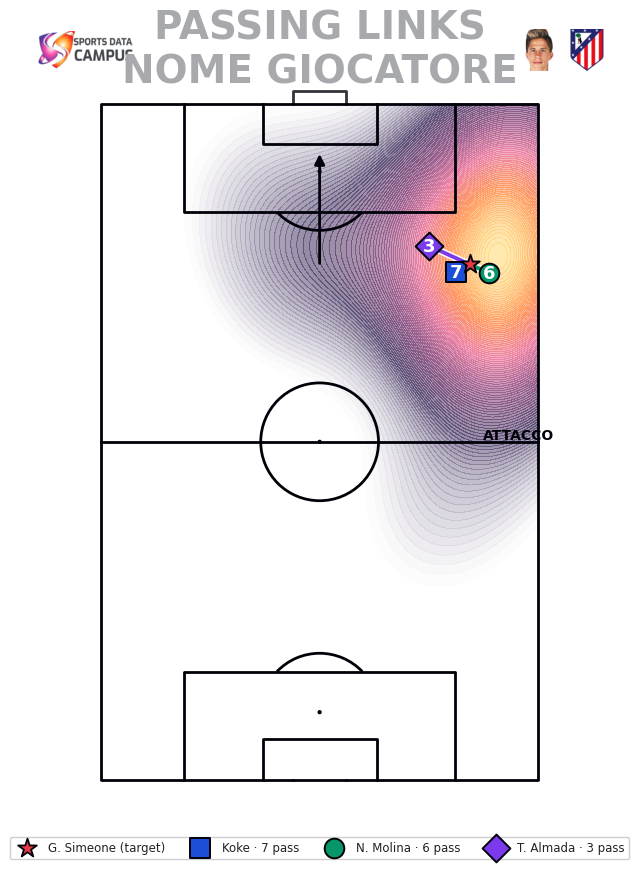

In [268]:
df_p = fetch_passer_recipient_passes(match_id=5718123, player_id=722567)

fig, ax = plot_passing_links_kde_vertical(
    df_p,
    "PASSING LINKS\nNOME GIOCATORE",
    add_header_branding=add_header_branding,
    player_img_source=out["player_image_data_url"],
    team_img_source=out["team_image_data_url"],
    pitch_half=False,
    kde_cmap=SDC_CMAP_WHITE0,       # o prova "PuBu" / SDC_CMAP_WHITE0 se vuoi brand
    kde_thresh=0.04,
    header_center_y=1.02
)
plt.show()

In [270]:
def fetch_target_received_passes(
    match_id: int,
    target_player_id: int,
    *,
    project_id: str | None = None,
    dataset: str = "scouting_agent",
    limit: int = 50000,
) -> pd.DataFrame:
    """
    Passaggi in cui recipient = target_player_id.
    start_* = da dove passa il compagno; end_* = dove riceve il target.
    """
    import os
    from google.cloud import bigquery

    pid = project_id or os.environ.get("GCP_PROJECT_ID")
    if not pid:
        raise ValueError("GCP_PROJECT_ID o project_id=")

    lim = max(1, min(int(limit), 100_000))
    fq = f"`{pid}.{dataset}.gold_match_pass_event`"
    dp = f"`{pid}.{dataset}.dim_player`"

    sql = f"""
    SELECT
      p.match_id,
      p.event_id,
      p.minute,
      p.second,
      p.location_x AS start_x,
      p.location_y AS start_y,
      p.pass_end_x AS end_x,
      p.pass_end_y AS end_y,
      p.player_id AS passer_id,
      pas.short_name AS passer_name,
      p.recipient_player_id AS target_id,
      tar.short_name AS target_name
    FROM {fq} AS p
    LEFT JOIN {dp} AS pas ON p.player_id = pas.player_id
    LEFT JOIN {dp} AS tar ON p.recipient_player_id = tar.player_id
    WHERE p.match_id = @match_id
      AND p.recipient_player_id = @target_player_id
      AND p.player_id IS NOT NULL
      AND p.pass_end_x IS NOT NULL
      AND p.pass_end_y IS NOT NULL
    ORDER BY p.minute, p.second, p.event_id
    LIMIT @limit
    """
    cfg = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("match_id", "INT64", int(match_id)),
            bigquery.ScalarQueryParameter("target_player_id", "INT64", int(target_player_id)),
            bigquery.ScalarQueryParameter("limit", "INT64", lim),
        ]
    )
    return bigquery.Client(project=pid).query(sql, job_config=cfg).to_dataframe()

In [273]:
def plot_received_passing_links_kde_vertical(
    df_passes: pd.DataFrame,
    title: str,
    *,
    add_header_branding,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source=None,
    player_img_source=None,
    pitch_half: bool = False,
    top_k: int = 3,
    figsize=(6.0, 8.0),
    kde_cmap="Blues",
    kde_levels: int = 256,
    kde_thresh: float = 0.035,
    kde_cut: int = 4,
    kde_bw_adjust: float = 1.5,
    kde_alpha: float = 0.55,
    show_kde_colorbar: bool = False,
    header_title_fontsize: float = 17,
    header_center_y: float = 0.93,
) -> tuple[plt.Figure, plt.Axes]:
    d = df_passes.copy()
    for c in ["start_x", "start_y", "end_x", "end_y"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.dropna(subset=["start_x", "start_y", "end_x", "end_y", "passer_id"])
    d = d[~((d["end_x"] == 0) & (d["end_y"] == 0))]
    if len(d) < 3:
        raise ValueError("Servono abbastanza passaggi ricevuti con coordinate.")

    target_name = (
        d["target_name"].dropna().astype(str).iloc[0]
        if "target_name" in d.columns
        else "Target"
    )

    # Hub ricezione (stella) = media dove riceve su tutti i passi in ingresso
    tx, ty = float(d["end_x"].mean()), float(d["end_y"].mean())

    g = (
        d.groupby(["passer_id", "passer_name"], dropna=False)
        .agg(
            n_pass=("event_id", "count"),
            sx=("start_x", "mean"),
            sy=("start_y", "mean"),
            ex=("end_x", "mean"),
            ey=("end_y", "mean"),
        )
        .reset_index()
        .sort_values("n_pass", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        half=pitch_half,
        pad_bottom=0.5,
        goal_type="box",
        goal_alpha=0.8,
        pitch_color="white",
        line_color="#000009",
        line_zorder=4,
    )
    fig, ax = pitch.draw(figsize=figsize)
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(left=0.07, right=0.94, top=0.86, bottom=0.20)

    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
        header_center_y=header_center_y,
    )

    ax.annotate(
        "",
        xy=(50, 93),
        xytext=(50, 76),
        arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#000009", mutation_scale=15),
        zorder=8,
    )
    pitch.text(50, 95.5, "ATTACCO", ax=ax, ha="center", va="bottom", fontsize=10, color="#000009", weight="bold", zorder=8)

    cmap_kde = plt.colormaps.get_cmap(kde_cmap).copy()
    cmap_kde.set_under("#ffffff")

    kde_ret = pitch.kdeplot(
        d["end_x"],
        d["end_y"],
        ax=ax,
        fill=True,
        levels=kde_levels,
        thresh=kde_thresh,
        cut=kde_cut,
        cmap=cmap_kde,
        bw_adjust=kde_bw_adjust,
        zorder=1,
        alpha=kde_alpha,
    )
    for coll in ax.collections:
        if coll.get_zorder() < 10:
            coll.set_zorder(2)

    if show_kde_colorbar:
        m = _kde_mappable(ax, cmap_kde, kde_ret)
        fig.colorbar(m, ax=ax, shrink=0.5, pad=0.02).set_label("Densità ricezioni", fontsize=9)

    pitch.scatter(
        tx, ty,
        s=520,
        marker="*",
        c="#e63946",
        edgecolors="#000009",
        linewidths=1.3,
        zorder=30,
        ax=ax,
        label=f"{target_name} · media ricezione",
    )

    markers = ["s", "o", "D", "^", "v"][:top_k]
    linecolors = ["#1d4ed8", "#059669", "#7c3aed", "#db2777", "#ea580c"][:top_k]

    for i, row in g.iterrows():
        sx, sy = float(row["sx"]), float(row["sy"])
        ex, ey = float(row["ex"]), float(row["ey"])
        n = int(row["n_pass"])
        pname = str(row["passer_name"]) if pd.notna(row["passer_name"]) else f"id {int(row['passer_id'])}"
        mc = linecolors[i % len(linecolors)]
        mk = markers[i % len(markers)]

        pitch.lines(sx, sy, ex, ey, ax=ax, color="white", linewidth=5.0, alpha=0.95, zorder=18, comet=False, transparent=False)
        pitch.lines(sx, sy, ex, ey, ax=ax, color=mc, linewidth=2.8, alpha=1.0, zorder=19, comet=False, transparent=False)

        pitch.scatter(
            sx, sy,
            s=720,
            marker=mk,
            facecolors=mc,
            edgecolors="#000009",
            linewidths=1.4,
            zorder=28,
            ax=ax,
            label=f"{pname} · {n} pass",
        )
        pitch.text(sx, sy, str(n), ax=ax, ha="center", va="center", fontsize=13, color="white", weight="bold", zorder=35)

    leg = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=2,
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        edgecolor="#cccccc",
        facecolor="white",
        fontsize=8.5,
    )
    for t in leg.get_texts():
        t.set_color("#222222")

    return fig, ax

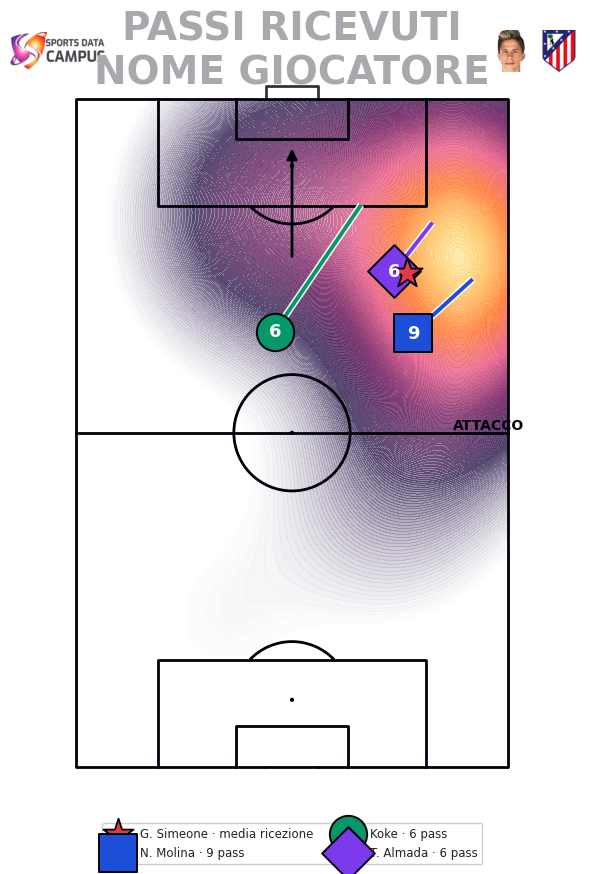

In [274]:
df_in = fetch_target_received_passes(match_id=5718123, target_player_id=722567)

fig, ax = plot_received_passing_links_kde_vertical(
    df_in,
    "PASSI RICEVUTI\nNOME GIOCATORE",
    add_header_branding=add_header_branding,
    player_img_source=out["player_image_data_url"],
    team_img_source=out["team_image_data_url"],
    pitch_half=False,
    kde_cmap=SDC_CMAP_WHITE0,       # o prova "PuBu" / SDC_CMAP_WHITE0 se vuoi brand
    kde_thresh=0.04,
    header_center_y=1.02
)
plt.show()

In [306]:
# --- Stile condiviso passing-link + KDE ---
PASS_VIZ_STAR_SIZE = 200
PASS_VIZ_NODE_SIZE = 200
PASS_VIZ_COUNT_FONTSIZE = 8
PASS_VIZ_LINE_WHITE_LW = 5.0
PASS_VIZ_LINE_COLOR_LW = 2.8
PASS_VIZ_MARKERS = ["o", "s", "D", "^", "v"]
PASS_VIZ_COLORS = ["#059669", "#1d4ed8", "#7c3aed", "#db2777", "#ea580c"]


def _kde_mappable(ax, cmap, kde_return):
    if kde_return is not None and not isinstance(kde_return, Axes):
        if hasattr(kde_return, "cmap") and kde_return.cmap is not None:
            return kde_return
    for ch in ax.get_children():
        if isinstance(ch, QuadContourSet) and ch.cmap is not None:
            return ch
    for coll in reversed(ax.collections):
        if getattr(coll, "cmap", None) is not None:
            return coll
    sm = cm.ScalarMappable(norm=Normalize(0, 1), cmap=cmap)
    sm.set_array(np.array([0, 1]))
    return sm

def _pitch_link_line(pitch, ax, x0, y0, x1, y1, color, z_white=18, z_col=19):
    # Conforme alla API mplsoccer, lines accetta:
    # pitch.lines(xstart, ystart, xend, yend, ax=..., color=..., **kwargs)
    xa = np.asarray([float(x0)], dtype=float)
    ya = np.asarray([float(y0)], dtype=float)
    xb = np.asarray([float(x1)], dtype=float)
    yb = np.asarray([float(y1)], dtype=float)

    # Freccia bianca sotto (più spessa)
    pitch.lines(
        xa, ya, xb, yb,
        ax=ax,
        color="white",
        linewidth=2.2,
        zorder=z_white,
        alpha=0.95,
        comet=False,      # per compatibilità mplsoccer, default False
        
    )

    # Freccia colorata sopra (più sottile)
    pitch.lines(
        xa, ya, xb, yb,
        ax=ax,
        color=color,
        linewidth=1.1,
        zorder=z_col,
        alpha=1.0,
        comet=False,
        
    )


def plot_passing_links_kde_vertical(
    df_passes: pd.DataFrame,
    title: str,
    *,
    add_header_branding,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source=None,
    player_img_source=None,
    pitch_half: bool = False,
    top_k: int = 3,
    figsize=(6.0, 8.0),
    kde_cmap: str = "Blues",
    kde_levels: int = 100,
    kde_thresh: float = 0.035,
    kde_cut: int = 4,
    kde_bw_adjust: float = 1.5,
    kde_alpha: float = 0.5,
    show_kde_colorbar: bool = False,
    header_title_fontsize: float = 17,
    header_center_y: float = 0.93,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Target = passatore. KDE sulle partenze. Stella = media uscita palla.
    Linee dalla stella alla media ricezione dei top_k riceventi.
    """
    d = df_passes.copy()
    for c in ["start_x", "start_y", "end_x", "end_y"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.dropna(subset=["start_x", "start_y", "end_x", "end_y", "recipient_id"])
    d = d[~((d["end_x"] == 0) & (d["end_y"] == 0))]
    if len(d) < 3:
        raise ValueError("Servono abbastanza passaggi con coordinate.")

    passer_name = (
        d["passer_name"].dropna().astype(str).iloc[0]
        if "passer_name" in d.columns
        else "Target"
    )

    sx = float(d["start_x"].median())
    sy = float(d["start_y"].median())

    g = (
        d.groupby(["recipient_id", "recipient_name"], dropna=False)
        .agg(n_pass=("event_id", "count"), rx=("end_x", "mean"), ry=("end_y", "mean"))
        .reset_index()
        .sort_values("n_pass", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        half=pitch_half,
        pad_bottom=0.5,
        goal_type="box",
        goal_alpha=0.8,
        pitch_color="white",
        line_color="#000009",
        line_zorder=4,
    )
    fig, ax = pitch.draw(figsize=figsize)
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(left=0.07, right=0.94, top=0.86, bottom=0.20)

    cmap_kde = plt.colormaps.get_cmap(kde_cmap).copy()
    cmap_kde.set_under("#ffffff")

    kde_ret = pitch.kdeplot(
        d["start_x"],
        d["start_y"],
        ax=ax,
        fill=True,
        levels=kde_levels,
        thresh=kde_thresh,
        cut=kde_cut,
        cmap=cmap_kde,
        bw_adjust=kde_bw_adjust,
        zorder=1,
        alpha=kde_alpha,
    )
    for coll in ax.collections:
        if coll.get_zorder() < 10:
            coll.set_zorder(2)

    if show_kde_colorbar:
        m = _kde_mappable(ax, cmap_kde, kde_ret)
        cb = fig.colorbar(m, ax=ax, shrink=0.5, pad=0.02)
        cb.set_label("Densità partenze", fontsize=9)

    

    pitch.scatter(
        sx, sy,
        s=PASS_VIZ_STAR_SIZE,
        marker="*",
        c="#e63946",
        edgecolors="#000009",
        linewidths=1.3,
        zorder=30,
        ax=ax,
        label=f"{passer_name} (target)",
    )

    for j, (_, row) in enumerate(g.iterrows()):
        rx, ry = float(row["rx"]), float(row["ry"])
        n = int(row["n_pass"])
        rname = str(row["recipient_name"]) if pd.notna(row["recipient_name"]) else f"id {int(row['recipient_id'])}"
        mc = PASS_VIZ_COLORS[j % len(PASS_VIZ_COLORS)]
        mk = PASS_VIZ_MARKERS[j % len(PASS_VIZ_MARKERS)]

        _pitch_link_line(pitch, ax, sx, sy, rx, ry, mc)

        pitch.scatter(
            rx, ry,
            s=PASS_VIZ_NODE_SIZE,
            marker=mk,
            facecolors=mc,
            edgecolors="#000009",
            linewidths=1.4,
            zorder=28,
            ax=ax,
            label=f"{rname} · {n} pass",
        )
        pitch.text(
            rx, ry, str(n),
            ax=ax,
            ha="center", va="center",
            fontsize=PASS_VIZ_COUNT_FONTSIZE,
            color="white", weight="bold",
            zorder=35,
        )

    leg = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=min(2, top_k + 1),
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        edgecolor="#cccccc",
        facecolor="white",
        fontsize=8.5,
    )
    for t in leg.get_texts():
        t.set_color("#222222")

    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
        header_center_y=header_center_y,
    )

    return fig, ax


def plot_received_passing_links_kde_vertical(
    df_passes: pd.DataFrame,
    title: str,
    *,
    add_header_branding,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source=None,
    player_img_source=None,
    pitch_half: bool = False,
    top_k: int = 3,
    figsize=(6.0, 8.0),
    kde_cmap: str = "Blues",
    kde_levels: int = 100,
    kde_thresh: float = 0.035,
    kde_cut: int = 4,
    kde_bw_adjust: float = 1.5,
    kde_alpha: float = 0.5,
    show_kde_colorbar: bool = False,
    header_title_fontsize: float = 17,
    header_center_y: float = 0.93,
    converge_lines_to_target: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Target = ricevente. KDE sulle ricezioni (end_x, end_y).
    Stella = media ricezione globale.
    Marker sui top_k passatori = media partenza dei loro passi verso il target.
    Linea: da (sx,sy) passatore a (tx,ty) stella se converge_lines_to_target,
           altrimenti a (ex,ey) media ricezione solo per quel passatore.
    """
    d = df_passes.copy()
    for c in ["start_x", "start_y", "end_x", "end_y"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.dropna(subset=["start_x", "start_y", "end_x", "end_y", "passer_id"])
    d = d[~((d["end_x"] == 0) & (d["end_y"] == 0))]
    if len(d) < 3:
        raise ValueError("Servono abbastanza passaggi ricevuti con coordinate.")

    target_name = (
        d["target_name"].dropna().astype(str).iloc[0]
        if "target_name" in d.columns
        else "Target"
    )

    tx = float(d["end_x"].median())
    ty = float(d["end_y"].median())

    g = (
        d.groupby(["passer_id", "passer_name"], dropna=False)
        .agg(
            n_pass=("event_id", "count"),
            sx=("start_x", "mean"),
            sy=("start_y", "mean"),
            ex=("end_x", "mean"),
            ey=("end_y", "mean"),
        )
        .reset_index()
        .sort_values("n_pass", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        half=pitch_half,
        pad_bottom=0.5,
        goal_type="box",
        goal_alpha=0.8,
        pitch_color="white",
        line_color="#000009",
        line_zorder=4,
    )
    fig, ax = pitch.draw(figsize=figsize)
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(left=0.07, right=0.94, top=0.86, bottom=0.20)

    cmap_kde = plt.colormaps.get_cmap(kde_cmap).copy()
    cmap_kde.set_under("#ffffff")

    kde_ret = pitch.kdeplot(
        d["end_x"],
        d["end_y"],
        ax=ax,
        fill=True,
        levels=kde_levels,
        thresh=kde_thresh,
        cut=kde_cut,
        cmap=cmap_kde,
        bw_adjust=kde_bw_adjust,
        zorder=1,
        alpha=kde_alpha,
    )
    for coll in ax.collections:
        if coll.get_zorder() < 10:
            coll.set_zorder(2)

    if show_kde_colorbar:
        m = _kde_mappable(ax, cmap_kde, kde_ret)
        cb = fig.colorbar(m, ax=ax, shrink=0.5, pad=0.02)
        cb.set_label("Densità ricezioni", fontsize=9)

    

    pitch.scatter(
        tx, ty,
        s=PASS_VIZ_STAR_SIZE,
        marker="*",
        c="#e63946",
        edgecolors="#000009",
        linewidths=1.3,
        zorder=30,
        ax=ax,
        label=f"{target_name} · media ricezione",
    )

    for j, (_, row) in enumerate(g.iterrows()):
        sx = float(row["sx"])
        sy = float(row["sy"])
        ex = float(row["ex"])
        ey = float(row["ey"])
        n = int(row["n_pass"])
        pname = str(row["passer_name"]) if pd.notna(row["passer_name"]) else f"id {int(row['passer_id'])}"
        mc = PASS_VIZ_COLORS[j % len(PASS_VIZ_COLORS)]
        mk = PASS_VIZ_MARKERS[j % len(PASS_VIZ_MARKERS)]

        x1, y1 = (tx, ty) if converge_lines_to_target else (ex, ey)
        _pitch_link_line(pitch, ax, sx, sy, x1, y1, mc)

        pitch.scatter(
            sx, sy,
            s=PASS_VIZ_NODE_SIZE,
            marker=mk,
            facecolors=mc,
            edgecolors="#000009",
            linewidths=1.4,
            zorder=28,
            ax=ax,
            label=f"{pname} · {n} pass",
        )
        pitch.text(
            sx, sy, str(n),
            ax=ax,
            ha="center", va="center",
            fontsize=PASS_VIZ_COUNT_FONTSIZE,
            color="white", weight="bold",
            zorder=35,
        )

    leg = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=min(2, top_k + 1),
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        edgecolor="#cccccc",
        facecolor="white",
        fontsize=8.5,
    )
    for t in leg.get_texts():
        t.set_color("#222222")

    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
        header_center_y=header_center_y,
    )

    return fig, ax

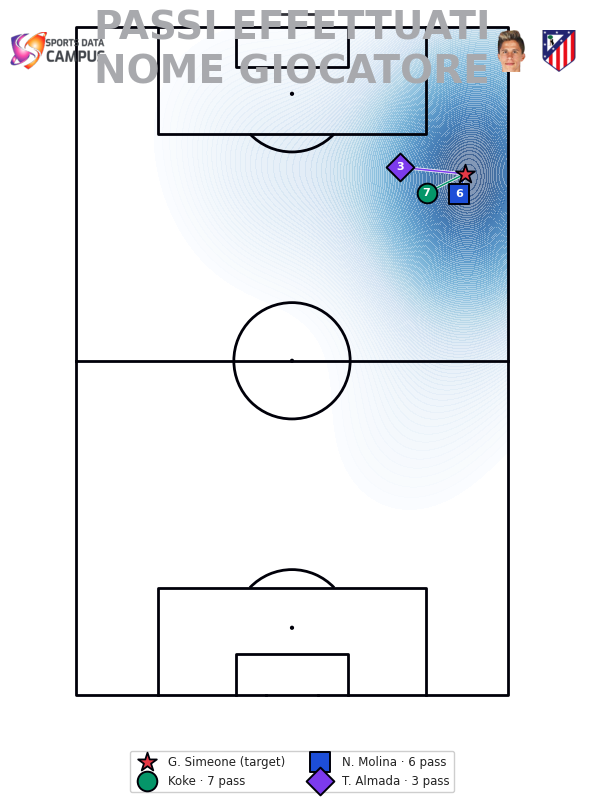

In [307]:
# dati (come già fai)
df_out = fetch_passer_recipient_passes(
    match_id=5718123,
    player_id=722567,
)

# immagini opzionali (stessa query dim di prima)
# out = {... player_image_data_url, team_image_data_url ...}

fig, ax = plot_passing_links_kde_vertical(
    df_out,
    "PASSI EFFETTUATI\nNOME GIOCATORE",
    add_header_branding=add_header_branding,
    left_logo_path="images/sport_data_campus.png",
    player_img_source=out.get("player_image_data_url"),
    team_img_source=out.get("team_image_data_url"),
    pitch_half=False,
    top_k=3,
)
plt.show()

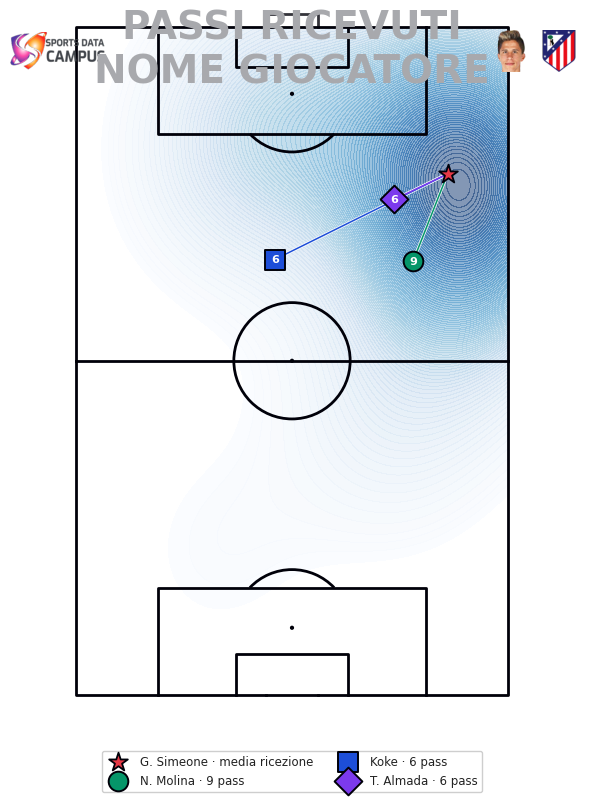

In [308]:
df_in = fetch_target_received_passes(
    match_id=5718123,
    target_player_id=722567,
)

fig, ax = plot_received_passing_links_kde_vertical(
    df_in,
    "PASSI RICEVUTI\nNOME GIOCATORE",
    add_header_branding=add_header_branding,
    player_img_source=out.get("player_image_data_url"),
    team_img_source=out.get("team_image_data_url"),
    pitch_half=False,
    top_k=3,
    converge_lines_to_target=True,   # tutte le linee finiscono sulla stella (media ricezione)
)
plt.show()

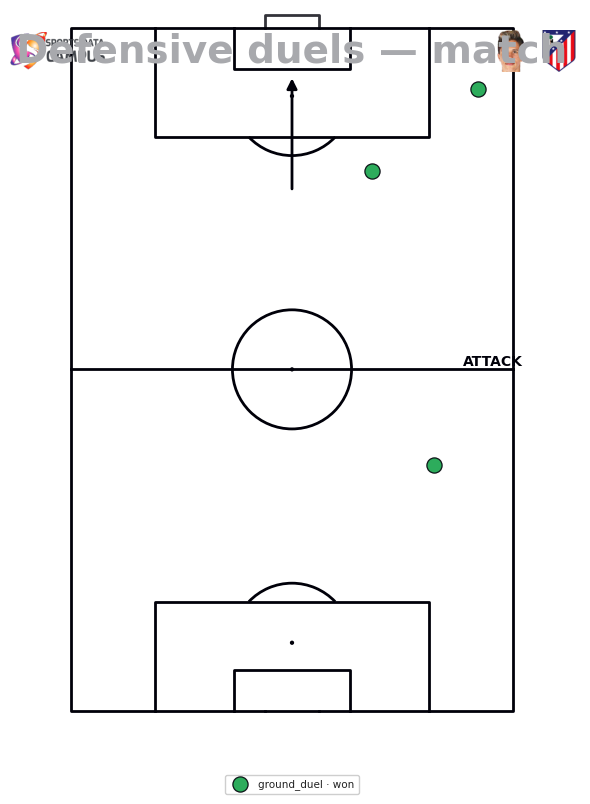

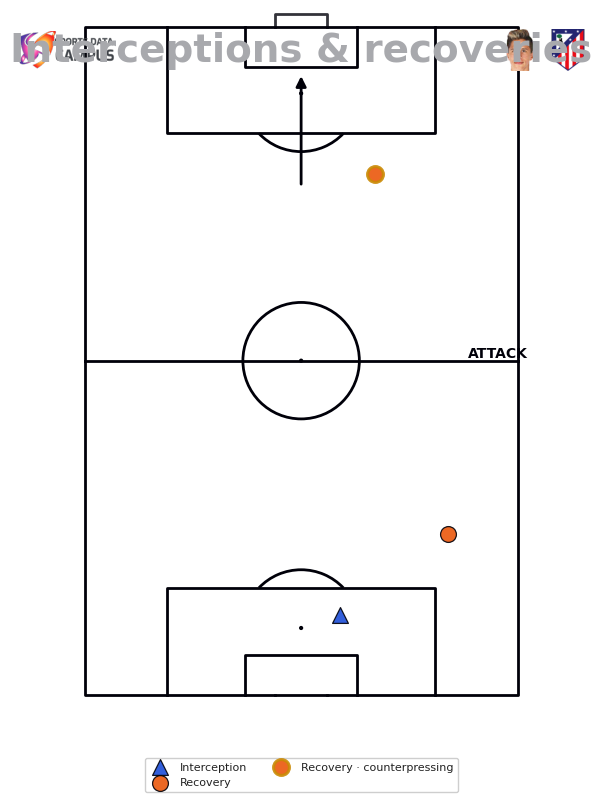

In [ ]:
import os
import matplotlib.pyplot as plt

from match_event_viz import (
    fetch_gold_match_defensive_duels,
    fetch_gold_match_recovery_interception,
    plot_defensive_duels_map_vertical,
    plot_recovery_interception_map_vertical,
)


MATCH_ID = 5718123  # <-- your match
TEAM_ID = None      # optional: filter one team
PLAYER_ID = 722567    # optional: filter one player


df_duels = fetch_gold_match_defensive_duels(
    MATCH_ID,
    team_id=TEAM_ID,
    player_id=PLAYER_ID,
)
fig1, ax1 = plot_defensive_duels_map_vertical(
    df_duels,
    title="Defensive duels — match",
    add_header_branding=add_header_branding,
    team_img_source=out.get("team_image_data_url"), 
    player_img_source=out.get("player_image_data_url")  # if you have URLs/paths
)
plt.show()

df_rec = fetch_gold_match_recovery_interception(
    MATCH_ID,
    team_id=TEAM_ID,
    player_id=PLAYER_ID,
)
fig2, ax2 = plot_recovery_interception_map_vertical(
    df_rec,
    title="Interceptions & recoveries",
    add_header_branding=add_header_branding,
    team_img_source=out.get("team_image_data_url"), 
    player_img_source=out.get("player_image_data_url")  # if you have URLs/paths
    h_
)
plt.show()